In [14]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import START, END, MessagesState
from langgraph.graph.state import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from datetime import datetime
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model


import random
import os
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
# class SupervisorState(MessagesState):
#     """State for supervising multi-agent workflow execution."""
#     current_agent: str = ""
#     task_assignments: Dict[str, Any] = {}
#     agent_outputs: Dict[str, Any] = {}
#     workflow_stage: str = "initial"
#     iteration_count: int = 0
#     max_iterations: int = 10
#     final_output: str = ""


class SupervisorState(MessagesState):
    """State for supervising multi-agent workflow execution."""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""
    


In [16]:
llm = init_chat_model("gpt-4o")

def create_supervisor_chain():
    """Creates a supervisor chain that oversees the multi-agent workflow."""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        (
            "system", 
            """
            
                You are a supervisor agent overseeing a multi-agent workflow. Your job is to monitor the agents, evaluate their outputs, and provide feedback to ensure the successful completion of the overall task.

                1. Researcher Agent: Responsible for gathering information and data relevant to the task.
                2. Analyst Agent: Responsible for analyzing the research data and providing insights.
                3. Writer Agent: Responsible for compiling the research and analysis into a final report.        

                Based on the current state and conversation, determine which agent should be active next, what feedback to provide to the agents, and when the task is complete. Your goal is to ensure that the final output is of high quality and meets the requirements of the task.
                If the task is complte, respond with 'DONE'.

                Current state:
                - Has research data: {has_research_data}
                - Has analysis: {has_analysis}
                - Has report: {has_report}

                Respond with only the agent name that should be active next (Researcher, Analyst, Writer) or 'DONE' if the task is complete.

            """
        ),
        ("human", "{task}")
    ])

    return supervisor_prompt | llm

In [17]:
from itertools import chain


def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor agent that decides which agent should be active next based on the current state."""
    
    messages = state["messages"]
    # task = messages[-1].content if messages else "No task provided."
    task = state.get("current_task") or (messages[-1].content if messages else "No task provided.")


    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))

    chain = create_supervisor_chain()
    # decision = chain.invoke(task=task, has_research_data=has_research, has_analysis=has_analysis, has_report=has_report)
    decision = chain.invoke({"task": task, "has_research_data": has_research, "has_analysis": has_analysis, "has_report": has_report})


    decision_text = decision.content.strip().lower()
    print(f"Supervisor decision: {decision_text}")

    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_message ="Supervisor: Task is complete. Final report is ready."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_message = "Supervisor: Researcher agent is active. Please gather relevant information and data."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_message = "Supervisor: Analyst agent is active. Please analyze the research data and provide insights."  
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_message = "Supervisor: Writer agent is active. Please compile the research and analysis into a final report."
    else:
        next_agent = "end"
        supervisor_message = "Supervisor: Unable to determine next agent. Ending workflow."

    return {
        "next_agent": next_agent,
        "messsages": [AIMessage(content=supervisor_message)],
        "current_task": task
    }

In [18]:
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher agent that gathers information and data relevant to the task."""
    task = state["current_task"]
    research_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a researcher agent. Your task is to gather information and data relevant to the following task: {task}. Provide a concise summary of your findings."),
        ("human", "{task}")
    ])

    chain = research_prompt | llm
    # research_output = chain.invoke(task=task)
    research_output = chain.invoke({"task": task})


    return {
        "research_data": research_output.content,
        "messages": [AIMessage(content=f"Researcher: Gathered research data for task '{task}'.")],
        "next_agent": "supervisor"
    }

In [19]:
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst agent that analyzes the research data and provides insights."""
    task = state["current_task"]
    research_data = state.get("research_data", "")

    analysis_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an analyst agent. Your task is to analyze the following research data and provide insights relevant to the task: {research_data}. Provide a concise summary of your analysis."),
        ("human", "{task}")
    ])

    chain = analysis_prompt | llm
    # analysis_output = chain.invoke(task=task, research_data=research_data)
    analysis_output = chain.invoke({"task": task, "research_data": research_data})


    return {
        "analysis": analysis_output.content,
        "messages": [AIMessage(content=f"Analyst: Analyzed research data for task '{task}'.")],
        "next_agent": "supervisor"
    }

In [20]:
def writer_agent(state: SupervisorState) -> Dict:
    """Writer agent that compiles the research and analysis into a final report."""
    task = state["current_task"]
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")

    writer_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a writer agent. Your task is to compile the following research data and analysis into a final report for the task: {task}. Research data: {research_data}. Analysis: {analysis}. Provide a concise and well-structured report."),
        ("human", "{task}")
    ])

    chain = writer_prompt | llm
    # report_output = chain.invoke(task=task, research_data=research_data, analysis=analysis)
    report_output = chain.invoke({"task": task, "research_data": research_data, "analysis": analysis})


    return {
        "final_report": report_output.content,
        "messages": [AIMessage(content=f"Writer: Compiled final report for task '{task}'.")],
        "next_agent": "supervisor"
    }

In [21]:
def router(state: SupervisorState) -> Literal["researcher", "analyst", "writer", "supervisor", "__end__"]:
    """Routes to the appropriate agent based on the current state."""
    
    next_agent = state.get("next_agent", "supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END

    if next_agent in ["researcher", "analyst", "writer", "supervisor"]:
        return next_agent
    
    return "supervisor"

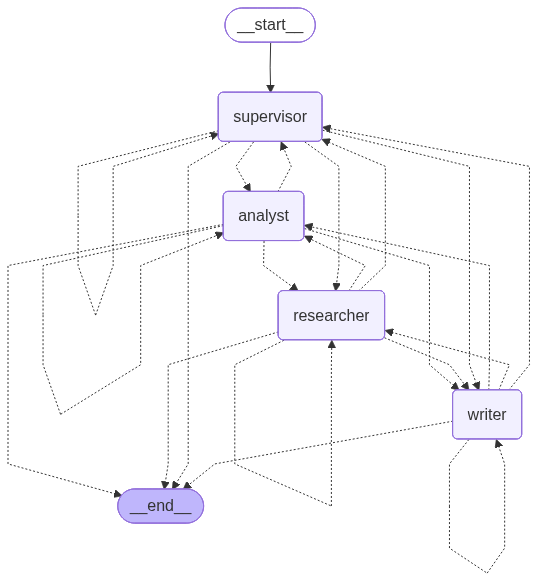

In [22]:
workflow = StateGraph(SupervisorState)


workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

workflow.set_entry_point("supervisor")
agents = ["supervisor", "researcher", "analyst", "writer"]
for node in agents:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            "supervisor": "supervisor",
            END: END
        }
    )

graph = workflow.compile()

graph



In [23]:
response = graph.invoke({"messages": [HumanMessage(content="The task is to write a report on the impact of climate change on coastal cities.")]})

Supervisor decision: researcher
Supervisor decision: analyst
Supervisor decision: writer
Supervisor decision: done


In [24]:
response['final_report']

'**Report on the Impact of Climate Change on Coastal Cities**\n\n**Introduction**\n\nClimate change significantly impacts coastal cities worldwide, presenting a myriad of interconnected challenges. These impacts, driven by rising global temperatures and changing environmental conditions, threaten populations, infrastructure, and ecosystems. This report discusses the primary issues faced by coastal cities due to climate change and the necessary strategies for mitigation and adaptation.\n\n**Key Impacts**\n\n1. **Sea Level Rise**: The increase in global temperatures leads to the melting of polar ice caps and glaciers, causing sea levels to rise. According to the Intergovernmental Panel on Climate Change (IPCC), global sea levels could rise by 0.26 to 0.82 meters by the end of the 21st century. This rise results in the inundation of low-lying areas, increased coastal erosion, and more frequent flooding, complicating urban planning and development efforts.\n\n2. **Increased Storm Intensity